## Minion Notebook

In [1]:
import os
python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

# Test
!pip --version

pip 25.3 from C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip (python 3.14)



In [2]:
# (requires) setup.py, run to show version of qickdawg installed
!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [6]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from copy import copy
import qickdawg as qd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from importlib.metadata import version
version('numpy')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'2.3.3'

In [7]:
qd.start_client('192.168.3.1')

### General Config

In [8]:
default_config = qd.NVConfiguration()

default_config.adc_channel = 0
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500


default_config.mw_channel = 0
default_config.mw_nqz = 1
default_config.mw_gain = 5000

default_config.laser_gate_pmod = 0

default_config.relax_delay_tns = 50 # between each rep, wait for everything to catch up, mostly aom



default_config.laser_on_tus = 2
default_config.laser_readout_offset_tus = 1.172
default_config.readout_integration_tns = 300
default_config.readout_reference_start_tus = 1.6
default_config.mw_laser_delay_treg = 0

default_config.relax_delay_tus = 1.1



### Laser On / Off

In [9]:
qd.laser_on(default_config)

0

In [10]:
qd.laser_off(default_config)

0

### PL Counts Scope

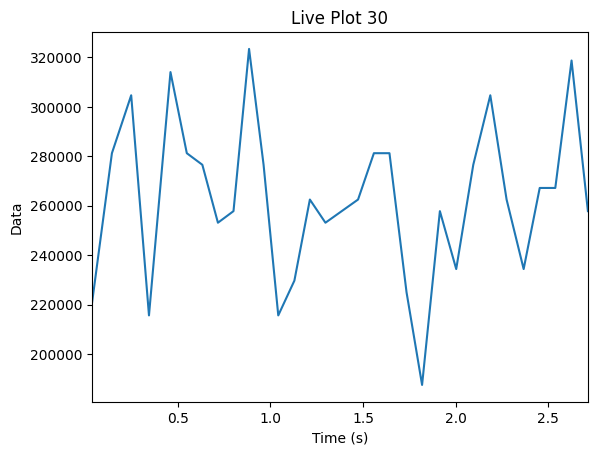

In [30]:
config = copy(default_config)

config.readout_integration_treg = 2**16-1 # Maxium number of integrated points
config.reps = 1 

prog = qd.PLIntensity(config) 

def get_cps():
    d = prog.acquire(progress=False)
    return d / qd.max_int_time_treg / qd.min_time_tns * 1e9

qd.live_plot(get_cps)

### PODMR

In [17]:
config = copy(default_config)

# Reps and Delays
config.pre_init = True 
config.reps = 600000

config.laser_on_tus = 2
config.laser_readout_offset_tus = 1.172
config.readout_integration_tns = 300
config.readout_reference_start_tus = 1.6
config.mw_laser_delay_treg = 0

config.relax_delay_tus = 1.1

config_lower = copy(config)

config_lower.mw_nqz = 1
config_lower.mw_gain = 1800
config_lower.mw_pi_tns = 650
center = 1847
width = 7
config_lower.add_linear_sweep('mw', 'fMHz', start=center-width, stop=center+width, delta=0.2)

prog = qd.PODMR(config_lower)
d_under = prog.acquire()


Requested 1840 to 1854 by 0.2
Instead using 1839.9999996185302 to 1854.000026321411 by 0.20000038146972654 in 71 steps


KeyboardInterrupt: 

In [36]:
config_upper = copy(config)

# Reps and Delays
config.pre_init = True 
config.reps = 600000


config_upper.mw_nqz = 2
config_upper.mw_gain = 12000
config_upper.mw_pi_tns = 186
center = 3895
width = 10
config_upper.add_linear_sweep('mw', 'fMHz', start=center-width, stop=center+width, delta=0.3)

prog = qd.PODMR(config_upper)
d_over = prog.acquire()


Requested 3885 to 3905 by 0.3
Instead using 3885.0 to 3904.7999999999997 by 0.3 in 67 steps


KeyboardInterrupt: 

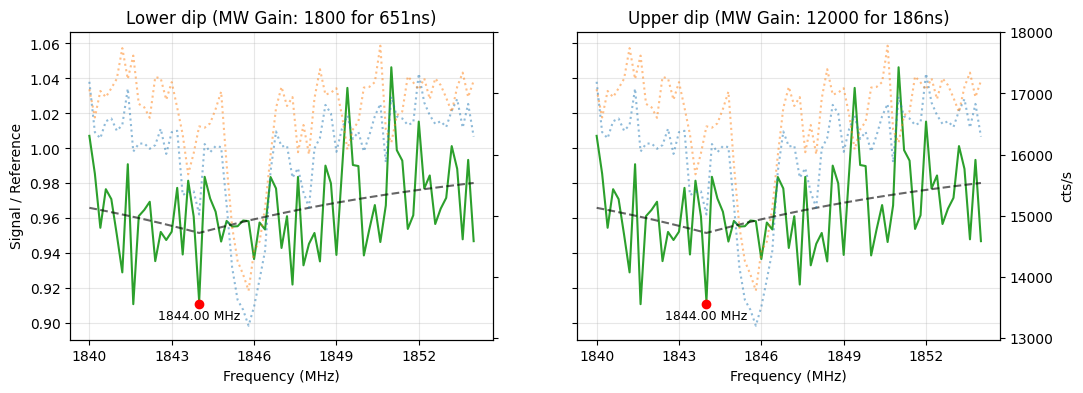

In [38]:
import numpy as np
import matplotlib.pyplot as plt

num_dips = 1

# --- Dip finding ---
def laplace_model(x, A, mu, b, C):
    return A * np.exp(-np.abs(x - mu) / b) + C

def fit_laplacian(freq, signal):
    A0 = np.min(signal) - 1
    mu0 = freq[np.argmin(signal)]
    b0 = np.sum(signal < 1 + A0/2) * (freq[1] - freq[0]) / (2 * np.log(2)) # half amplitude width 

    popt, _ = curve_fit(
        laplace_model,
        freq,
        signal,
        p0=[A0, mu0, b0, 1],
        maxfev=5000
    )

    A, mu, b, C = popt
    return A, mu, b, C

def plot_fit(freq, signal, axis):
    A, mu, b, C = fit_laplacian(freq, signal)
    fit_curve = laplace_model(freq, A, mu, b, C)

    axis.plot(freq, fit_curve, color='black', linestyle="--", alpha=0.6)

    # axis.plot(mu, C+A, 'ro')

    # axis.annotate(
    #     f"{mu:.2f} MHz",
    #     xy=(mu, C+A),
    #     xytext=(0, -11),
    #     textcoords="offset points",
    #     ha="center",
    #     fontsize=9
    # )

    ymin = signal[np.argmin(signal)]

    axis.plot(mu, ymin, 'ro')

    axis.annotate(
        f"{mu:.2f} MHz",
        xy=(mu, ymin),
        xytext=(0, -11),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

    return mu



# --- Compute ratios ---
ratio_under = d_under.signal / d_under.reference
d_over = d_under
ratio_over  = d_over.signal  / d_over.reference

dip_freqs = []

# =======================
# GLOBAL SCALING (CRITICAL)
# =======================

# Ratio (signal / reference)
ratio_all = np.concatenate((ratio_under, ratio_over))
rmin, rmax = np.nanmin(ratio_all), np.nanmax(ratio_all)
rpad = 0.15 * (rmax - rmin)
ratio_ylim = (rmin - rpad, rmax + rpad)

# Counts (signal + reference)
counts_all = np.concatenate((
    d_under.signal, d_under.reference,
    d_over.signal,  d_over.reference
))
cmin, cmax = np.nanmin(counts_all), np.nanmax(counts_all)
cpad = 0.05 * (cmax - cmin)
counts_ylim = (cmin - cpad, cmax + cpad)

# =======================
# FIGURE
# =======================

fig, (axL, axR) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(12, 4),
    gridspec_kw={"wspace": 0.2}
)

# =======================
# Left panel: Lower dip
# =======================

axL.plot(d_under.frequencies, ratio_under, color="tab:green")

axL.set_title(f"Lower dip (MW Gain: {config_lower.mw_gain:0.0f} for {config_lower.mw_pi_tns:0.0f}ns)")
axL.set_xlabel("Frequency (MHz)")
axL.set_ylabel("Signal / Reference")
axL.grid(alpha=0.3)

axL2 = axL.twinx()
axL2.plot(d_under.frequencies, d_under.signal,
          color="tab:blue", alpha=0.5, linestyle=":")
axL2.plot(d_under.frequencies, d_under.reference,
          color="tab:orange", alpha=0.5, linestyle=":")
axL2.tick_params(labelright=False)

plot_fit(d_under.frequencies, ratio_under, axL)

# =======================
# Right panel: Upper dip
# =======================

axR.plot(d_over.frequencies, ratio_over, color="tab:green")

axR.set_title(f"Upper dip (MW Gain: {config_upper.mw_gain:0.0f} for {config_upper.mw_pi_tns:0.0f}ns)")
axR.set_xlabel("Frequency (MHz)")
axR.grid(alpha=0.3)

axR2 = axR.twinx()
axR2.plot(d_over.frequencies, d_over.signal,
          color="tab:blue", alpha=0.5, linestyle=":")
axR2.plot(d_over.frequencies, d_over.reference,
          color="tab:orange", alpha=0.5, linestyle=":")
axR2.set_ylabel("cts/s")

plot_fit(d_over.frequencies, ratio_over, axR)


# =======================
# ENFORCE SHARED SCALING
# =======================

axL.set_ylim(ratio_ylim)
axR.set_ylim(ratio_ylim)

axL2.set_ylim(counts_ylim)
axR2.set_ylim(counts_ylim)

from matplotlib.ticker import MaxNLocator

for ax in [axL, axR]:
    ax.xaxis.set_major_locator(MaxNLocator(6))  # max 5 ticks

plt.show()

In [44]:
# Saving Data
import os
from datetime import datetime
import pandas as pd

run_dir = f"widescans"
os.makedirs(run_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")


freqs = d_under.frequencies
signal = d_under.signal
reference = d_under.reference

df = pd.DataFrame({
    "frequency_MHz": freqs,
    "signal (cts/s)": signal,
    "reference (cts/s)": reference,
    "ratio": signal / reference,
    "timestamp": timestamp
})

df.to_csv(os.path.join(run_dir, f"podmr_hyperfine_polarized_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.csv"), index=False)

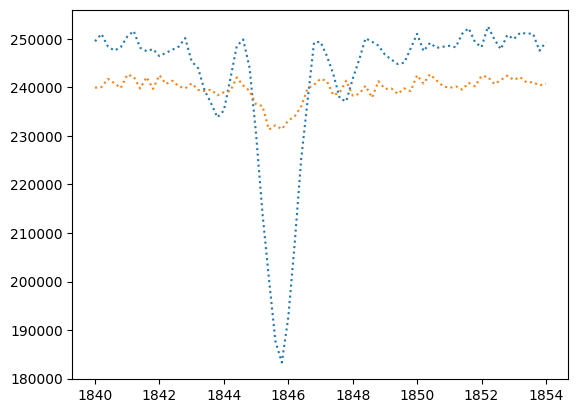

In [56]:
plt.plot(d_under.frequencies, d_under.signal,
          color="tab:blue", linestyle=":")
plt.plot(d_under.frequencies, d_under.reference,
          color="tab:orange", linestyle=":")

### RABI

In [21]:
config = copy(default_config)

config.relax_delay_tus = 2


config.mw_nqz = 1
config.mw_gain = 8000
config.mw_fMHz = 1845.73

config.pre_init=True

config.relax_delay_tus=1.5

config.laser_on_tus = 3.5 # in us
config.readout_integration_tns = 300  # us
config.readout_reference_start_tus = 2 # us

config.mw_readout_delay_treg = 0
config.laser_readout_offset_tus = 1.172 #

config.add_linear_sweep('mw', 'tns', start=15, stop=1000, delta=15)

config.reps = 1000000

prog = qd.RabiSweep(config)
d = prog.acquire(progress=True)


Requested 15 to 1000 by 15
Instead using 16.276041666666668 to 1074.21875 by 16.276041666666668 in 66 steps


100%|██████████| 66000000/66000000 [12:12<00:00, 90157.09it/s]


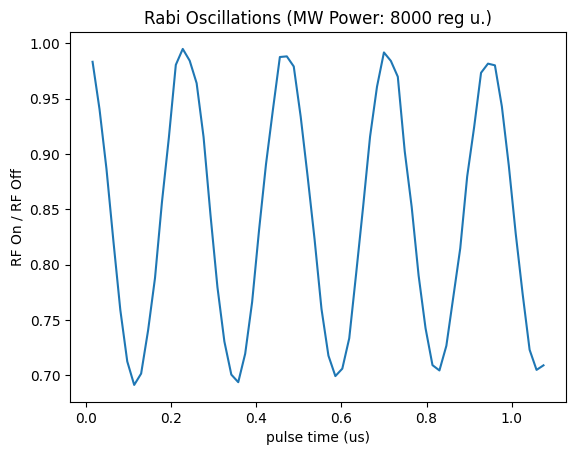

In [22]:
plt.plot(d.sweep_tus, d.signal1/d.signal2)

plt.title(f'Rabi Oscillations (MW Power: {config.mw_gain} reg u.)')
plt.ylabel('RF On / RF Off')
plt.xlabel('pulse time (us)')
plt.show()


Pi/2 pulse is approximately 59 ns
[ 0.15488693  0.23603748  0.8450051  10.62032033]


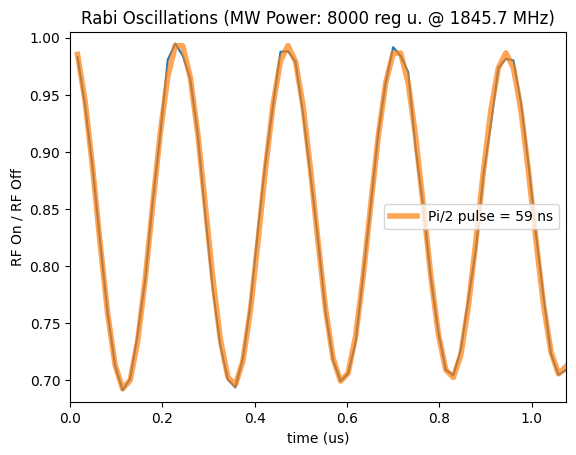

In [23]:
def decaying_cos(x, A, T, C, tau):

    return -A * (np.cos(x*2*np.pi/T- np.pi))*np.exp(-x/tau) + C

p0 = [0.15, 0.25, 0.85, 0.5]

t = d.sweep_tus
x = d.signal1/d.signal2

param, _ = curve_fit(decaying_cos, t, x, p0 = p0)

plt.plot(d.sweep_tus, d.signal1/d.signal2)

plt.plot(t, decaying_cos(t, *param), linewidth=4, alpha=0.7, label='Pi/2 pulse = {:.0f} ns'.format(param[1]*1000/4))
plt.title(f'Rabi Oscillations (MW Power: {config.mw_gain} reg u. @ {config.mw_fMHz:0.1f} MHz)')
plt.ylabel('RF On / RF Off')
plt.xlabel('time (us)')
plt.xlim(0, np.max(t))
plt.ylim(np.min(x)-0.01, np.max(x)+.01)
print('Pi/2 pulse is approximately {:.0f} ns'.format(param[1]*1000/4))
plt.vlines(param[1]/4, np.min(d.contrast), 0)
plt.legend()

print(param)


## CD Curves

In [ ]:
config = copy(default_config)

config.mw_gain = 10000
config.mw_fMHz = 1845.7
config.mw_pi2_tns = 59*2

config.pre_init=True

config.relax_delay_tus=0.51

config.laser_on_tus = 15
config.readout_integration_tns = 20
config.readout_reference_start_tus = 12 # near end of laser pulse

config.mw_readout_delay_treg = 50
config.laser_readout_offset_treg = 0

config.reps=1000000

for i in range(40):

    config.laser_readout_offset_treg = i * config.readout_integration_treg

    prog = qd.IntegratedReadoutWindow(config)

    d = prog.acquire()

    if i ==0:
        results = d
        results.delay = np.array([config.laser_readout_offset_treg])
    else:
        for key in d.keys():
            results[key] = np.append(results[key], d[key])
        results.delay = np.append(results.delay, [config.laser_readout_offset_treg])

KeyboardInterrupt: 

In [ ]:
plt.plot(results.signal1)
plt.plot(results.signal2)
plt.plot(results.reference1)
plt.plot(results.reference2)

In [ ]:
# Here we plot the readout window data for the microwave pluse on and the microwave off
data_off = results.signal2
data_on = results.signal1

t = np.array(results.delay) * qd.min_time_tus
x = data_on
x2 = data_off

plt.plot(t, x/np.max(x), linewidth=4)
plt.plot(t, x2/np.max(x), linewidth=4) 

plt.legend(['MW on', 'MW off'])
plt.xlabel('time (us)')
plt.ylabel('PL intensity (A.U.)')
# plt.xlim(0, 190)
# plt.ylim(0, 1.1)
plt.show()

plt.plot(t, x - x2, c='red', linewidth=4)
plt.ylabel('Difference')
plt.xlabel('time (us)')
plt.xlim(0, )
plt.show()

print('laser_readout_offset is approximately {} register units'.format(results.delay[np.where(x/np.max(x) > 0.8)[0][0]]))
config.one_tus = 1
print('approximately {} us'.format(np.round(results.delay[np.where(x/np.max(x) > 0.8)[0][0]]/config.one_treg,3)))

# 200 ps RABI

In [ ]:
config = copy(default_config)

config.mw_nqz # 1 at 1405 MHz
config.mw_fMHz = 200
config.mw_gain = 2000
config.reps = 2

config.mw_start_tsamp = 500
config.mw_end_tsamp = 502
config.nsweep_points = 2

# Laser params
config.laser_init_tus = 1

# Readout and delays
config.readout_integration_tns = 300
config.mw_to_laser_delay_tns = 505
config.laser_readout_offset_tus = 1.2

prog = qd.RABI_SUBNANO(config)
d = prog.acquire(progress=True)

AssertionError: Missing value for config.mw_to_laser_delay_treg